Many of the ideas in this tutorial are simplified versions of what is discussed in 

```
    Priebe, C. E., Park, Y., Vogelstein, J. T., Conroy, J. M., Lyzinski, V., Tang, M., ... & Bridgeford, E. (2019). On a two-truths phenomenon in spectral graph clustering. Proceedings of the National Academy of Sciences, 116(13), 5995-6000.
```

Create an affinity network

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


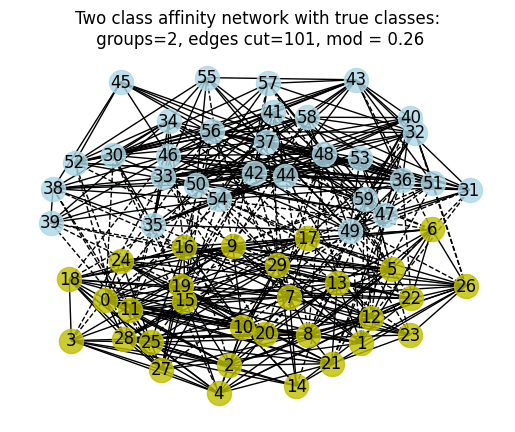

In [431]:
##############
### Cell 1 ###
##############

## REQUIRES pip install scikit-learn

from drawing_utilities import show_dendrogram
from drawing_utilities import show_partitions
from drawing_utilities import show_kCores
from drawing_utilities import show_kCores_by_partition
from drawing_utilities import show_2D_scatterplot
from partitioning_utilities import get_k_fiedler_eigenvectors_sparse
from partitioning_utilities import get_k_principal_eigenvectors_sparse
from partitioning_utilities import get_colors_from_clusters
import networkx as nx

%load_ext autoreload

a = 0.4
b = 0.1
c = 0.4
num_nodes: int = 30
G: nx.Graph = nx.stochastic_block_model([num_nodes,num_nodes],[[a, b],[b,c]])

partition_dict: dict[int, set[int]] = {0: set(), 1: set()}
for node in G.nodes():
    if node < num_nodes:
        partition_dict[0].add(node)
    else:
        partition_dict[1].add(node)
partition: list[set[int]] = list(partition_dict.values())

show_partitions(G, partition, title="Two class affinity network with true classes:\n")

Look at dendrogram

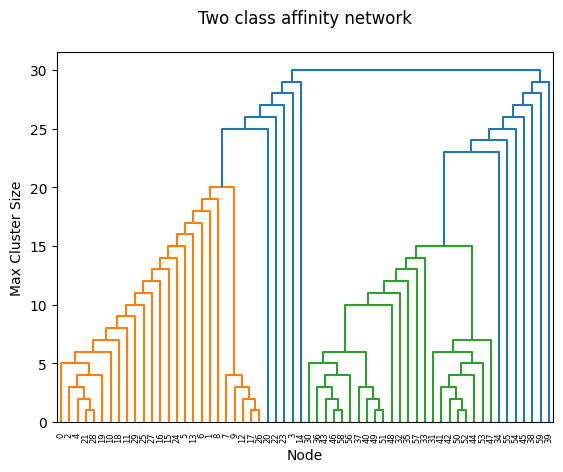

In [432]:
##############
### Cell 2 ###
##############
import networkx as nx
from copy import deepcopy
def largest_component(graph):
    # Find all connected components
    H = deepcopy(graph)
    components = nx.connected_components(H)
    # Get the largest component
    largest = max(components, key=len)
    H = deepcopy(H.subgraph(largest))
    mapping = {old_label: new_label for new_label, old_label in enumerate(G.nodes())}
    H = nx.relabel_nodes(H, mapping)
    return H

H = largest_component(G)
show_dendrogram(H, height_metric="max_cluster", title="Two class affinity network\n")

Look at kcores

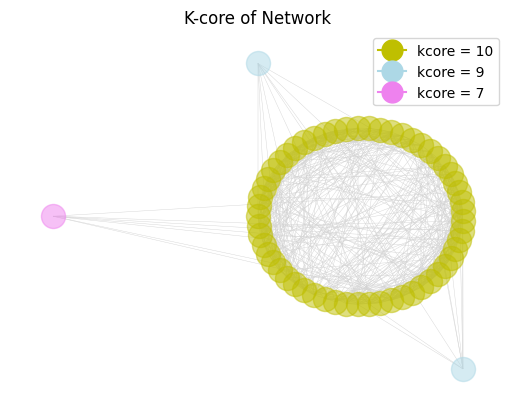

In [433]:
##############
### Cell 3 ###
##############
show_kCores(G)

Get first and second fiedler vector

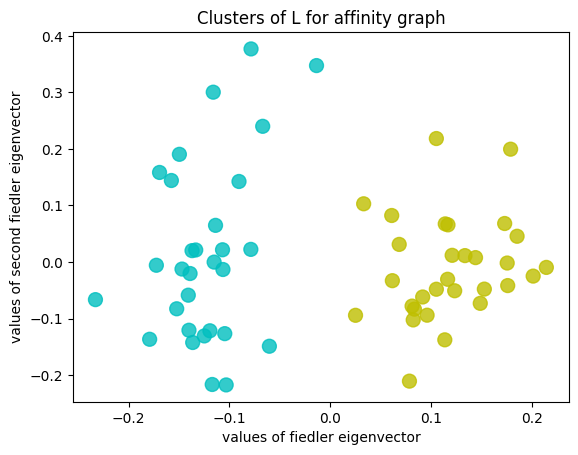

In [434]:
##############
### Cell 4 ###
##############

%autoreload 2

L = nx.linalg.normalized_laplacian_matrix(G)
fiedler_vectors = get_k_fiedler_eigenvectors_sparse(L, 2)
colors = get_colors_from_clusters(fiedler_vectors, num_clusters=2)
show_2D_scatterplot(fiedler_vectors[:,0],
                    fiedler_vectors[:,1],
                    colors,
                    xlabel = "values of fiedler eigenvector",
                    ylabel = "values of second fiedler eigenvector",
                    title = "Clusters of L for affinity graph")


Show graph partitioned into two clusters using the Laplacian embedding

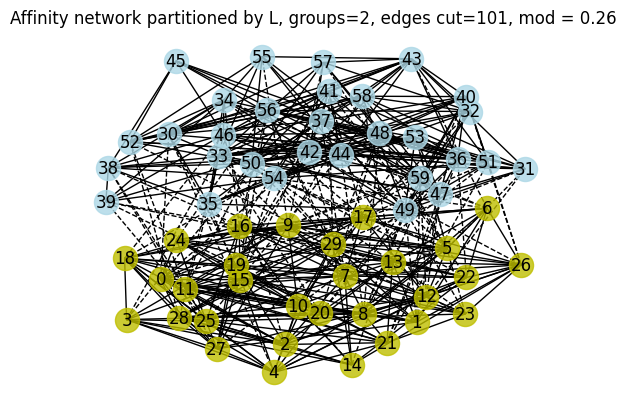

In [435]:
##############
### Cell 5 ###
##############
group1 = {node for node in G.nodes() if colors[node] == 'y'}
group2 = {node for node in G.nodes() if colors[node] == 'c'}

show_partitions(G, partition=(group1, group2), title="Affinity network partitioned by L")

Repeat but partition using adjacency matrix

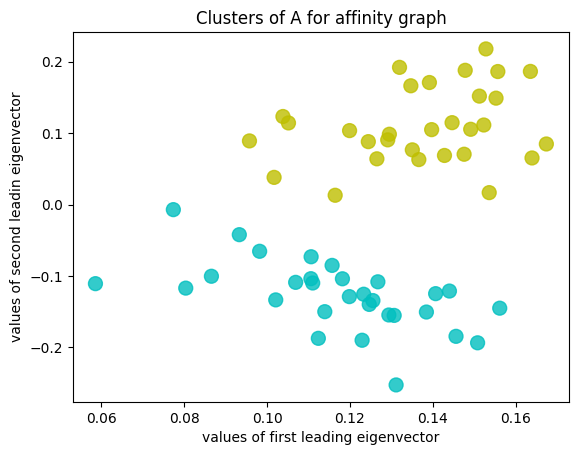

In [436]:
##############
### Cell 6 ###
##############
A = nx.linalg.adjacency_matrix(G)
leading_vectors = get_k_principal_eigenvectors_sparse(A, 2)
colors = get_colors_from_clusters(leading_vectors, num_clusters=2)

show_2D_scatterplot(leading_vectors[:,0],
                    leading_vectors[:,1],
                    colors,
                    xlabel = "values of first leading eigenvector",
                    ylabel = "values of second leadin eigenvector",
                    title = "Clusters of A for affinity graph")


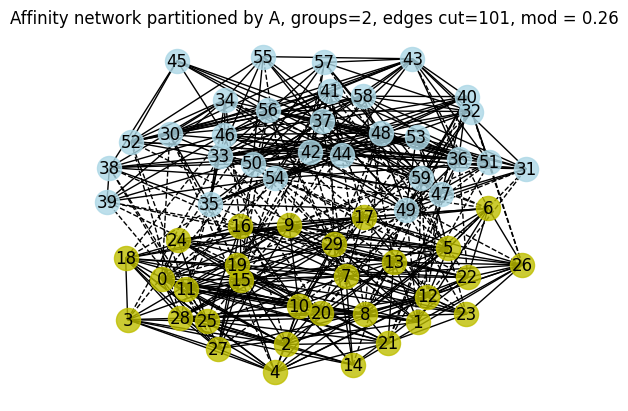

In [437]:
##############
### Cell 7 ###
##############
group1 = {node for node in G.nodes() if colors[node] == 'y'}
group2 = {node for node in G.nodes() if colors[node] == 'c'}

show_partitions(G, partition=(group1, group2), title="Affinity network partitioned by A")

Redraw to see which node classes belong n core and which belong in the periphery

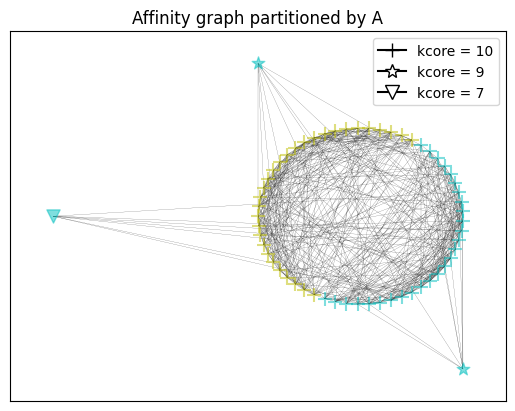

In [438]:
##############
### Cell 8 ###
##############

show_kCores_by_partition(G, colors, title="Affinity graph partitioned by A")

---

Create a core-periphery network

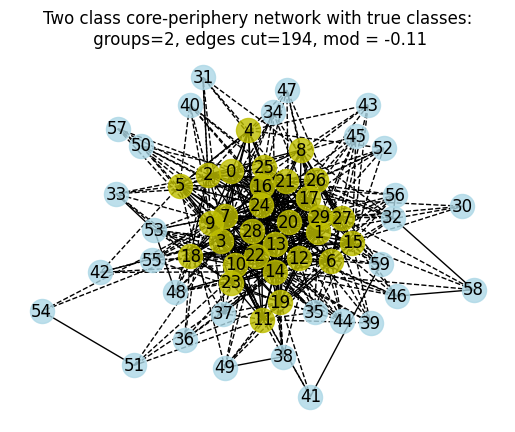

In [439]:
##############
### Cell 9 ###
##############

a = 0.4
b = 0.2
c = 0.01
G: nx.Graph = nx.stochastic_block_model([num_nodes,num_nodes],[[a,b],[b,c]])

partition_dict: dict[int, set[int]] = {0: set(), 1: set()}
for node in G.nodes():
    if node < num_nodes:
        partition_dict[0].add(node)
    else:
        partition_dict[1].add(node)
partition: list[set[int]] = list(partition_dict.values())

show_partitions(G, 
                pos = nx.spring_layout(G),
                partition = partition, 
                title="Two class core-periphery network with true classes:\n")



Look at dendrogram

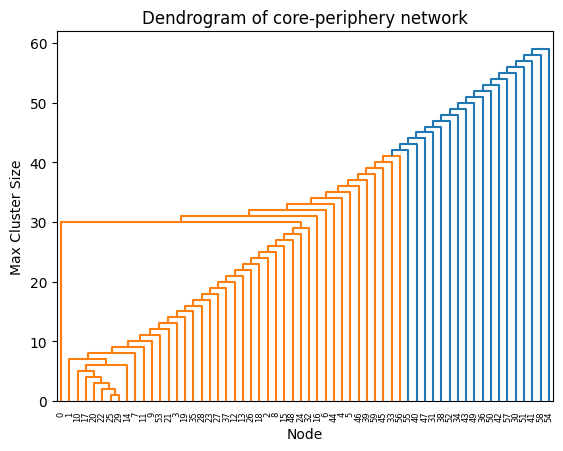

In [440]:
###############
### Cell 10 ###
###############

#G = largest_component(G)
show_dendrogram(G,title="Dendrogram of core-periphery network", height_metric="max_cluster")

Look at kcores

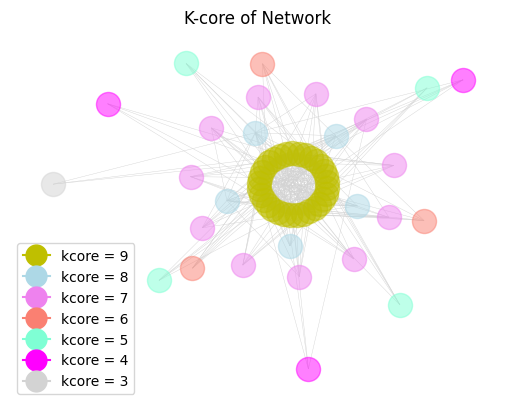

In [441]:
###############
### Cell 11 ###
###############

show_kCores(G)

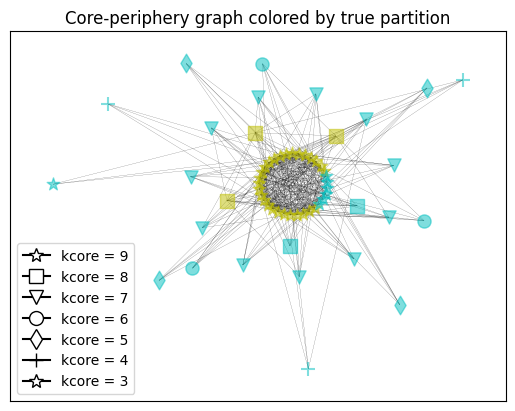

In [442]:
#################
### Cell 11.5 ###
#################

# Show k-cores colored by the original graph
colors = ['y' if node in partition[0] else 'c' for node in G.nodes()]

show_kCores_by_partition(G, colors = colors, title="Core-periphery graph colored by true partition")

The yellow vertices are from the core and the cyan vertices are from the periphery. The shells layout does a pretty good job showing that nodes in the core appear in the largest k-cores of the graph.

Let's partition using the normalized Laplacian matrix

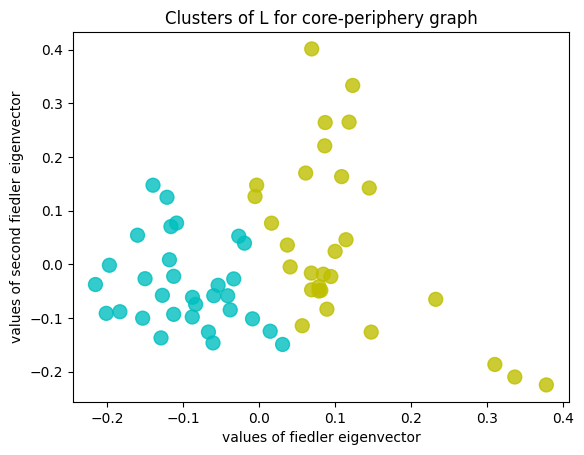

In [443]:
###############
### Cell 12 ###
###############

L = nx.linalg.normalized_laplacian_matrix(G)
fiedler_vectors = get_k_fiedler_eigenvectors_sparse(L, 2)
colors = get_colors_from_clusters(fiedler_vectors, num_clusters=2)
show_2D_scatterplot(fiedler_vectors[:,0],
                    fiedler_vectors[:,1],
                    colors,
                    xlabel = "values of fiedler eigenvector",
                    ylabel = "values of second fiedler eigenvector",
                    title = "Clusters of L for core-periphery graph")

Show partition

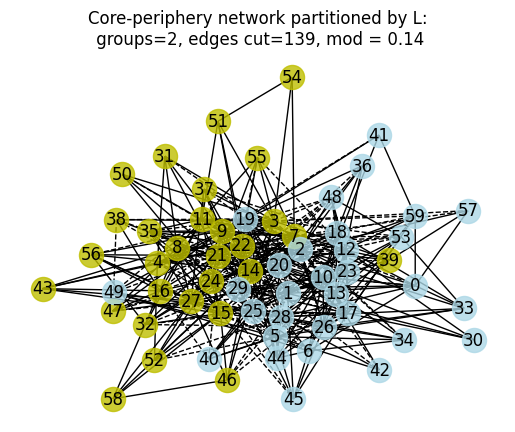

In [444]:
###############
### Cell 13 ###
###############
group1 = {node for node in G.nodes() if colors[node] == 'y'}
group2 = {node for node in G.nodes() if colors[node] == 'c'}


# Spring layout tends to show core periphery structure well
show_partitions(G, 
                pos = nx.spring_layout(G),
                partition=(group1, group2), 
                title="Core-periphery network partitioned by L:\n")

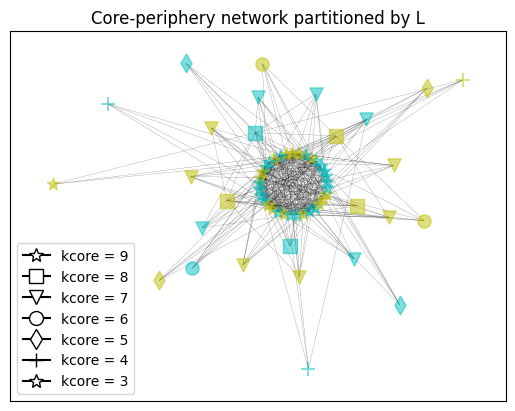

In [445]:
###############
### Cell 14 ###
###############
show_kCores_by_partition(G,colors,title = "Core-periphery network partitioned by L")

Partitioning by the eigenvectors of L doesn't do a good job of forming a community of core nodes and another community of peripheral nodes. You can see that by observing how the node class found by clustering eigenvectors of L don't correlate with which k-core the nodes falls in.

Repeat using the adjacency matrix

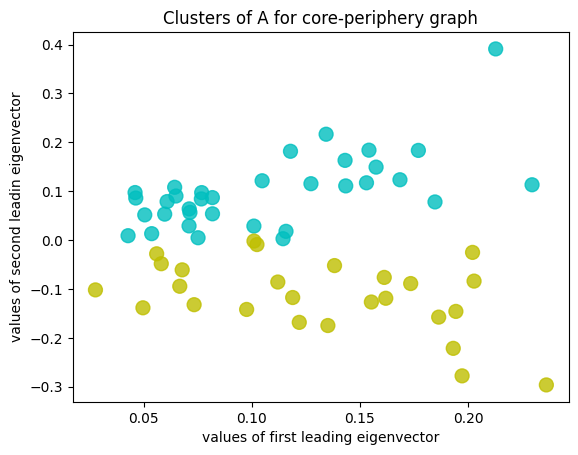

In [446]:
###############
### Cell 15 ##
###############

A = nx.linalg.adjacency_matrix(G)
leading_vectors = get_k_principal_eigenvectors_sparse(A, 2)
colors = get_colors_from_clusters(leading_vectors, num_clusters=2)

show_2D_scatterplot(leading_vectors[:,0],
                    leading_vectors[:,1],
                    colors,
                    xlabel = "values of first leading eigenvector",
                    ylabel = "values of second leadin eigenvector",
                    title = "Clusters of A for core-periphery graph")

Show partition by adjacency matrix

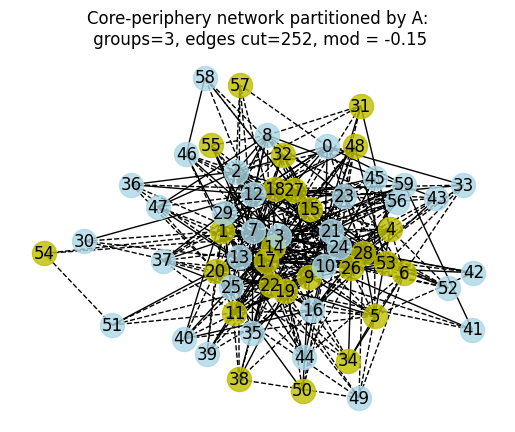

In [447]:
###############
### Cell 16 ###
###############

group1 = {node for node in G.nodes() if colors[node] == 'y'}
group2 = {node for node in G.nodes() if colors[node] == 'c'}
group3 = {node for node in G.nodes() if colors[node] == 'm'}
#group4 = {node for node in G.nodes() if colors[node] == 'k'}


# Spring layout tends to show core periphery structure well
show_partitions(G, 
                pos = nx.spring_layout(G),
                partition=(group1, group2,group3), 
                title="Core-periphery network partitioned by A:\n")

Redraw using the shell layout to see which class falls in core and which in periphery

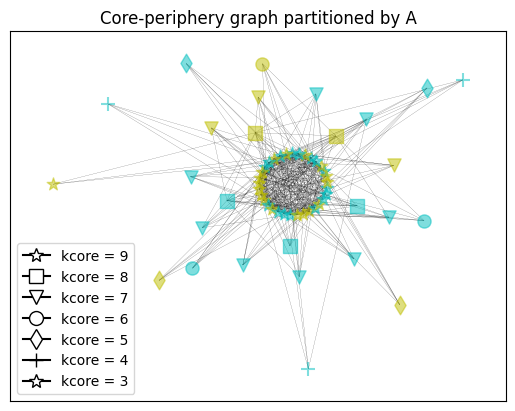

In [448]:
###############
### Cell 17 ###
###############
show_kCores_by_partition(G,colors, title="Core-periphery graph partitioned by A")

It looks like many of the nodes of similar colors are in the 3-core, which suggests that the clustering by the eigenvectors of the adjacency matrix pull out at least some information about the k-core structure. How well the clusters of the eigenvectors of A pull out core and periphery communities is really sensitive to random things in the process.

Perhaps the problem is that the graph is too complicated to be split into core and periphery using only two eigenvectors. Let's use more eigenvectors of the adjacency matrix in a higher dimensional space, cluster in that higher space, and the partition by cluster.

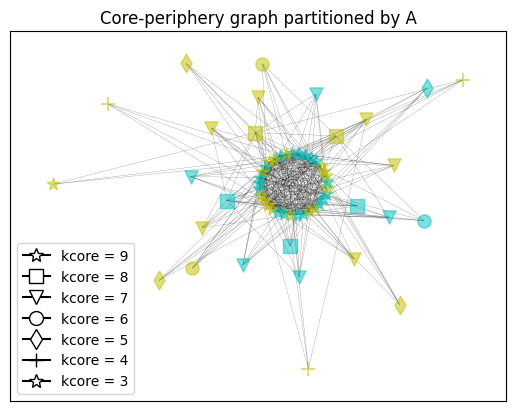

In [449]:
## Use more eigenvectors of the adjacency matrix to get a better partitioning of the core-periphery graph
num_eigenvectors = 10

A = nx.linalg.adjacency_matrix(G)
leading_vectors = get_k_principal_eigenvectors_sparse(A, num_eigenvectors)
colors = get_colors_from_clusters(leading_vectors, num_clusters=2)

show_kCores_by_partition(G,colors, title="Core-periphery graph partitioned by A")

This is no better.

---

### Where Will Adjacency Matrix Sprectral Clustering Work?

The reason to believe that spectral clustering will work on eigenvectors of the adjacency matrix is that some graphs have nodes that have very similar centrality values. The reason to believe this kind of spectral clustering will work for core-periphery networks is because nodes in the core should have similar centrality values and nodes in the periphery should also have similar eigenvector centrality scores. Let's illustrate this with the graph used in class. 

In [450]:
###############
### Cell 18 ###
###############

pinwheel_graph: nx.Graph = nx.Graph()
pinwheel_graph.add_nodes_from([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
pinwheel_graph.add_edges_from([(0,1), (0,2), (1,2),
                                (3,4), (3,5), (4,5),
                                (6,7), (6,8), (7,8),
                                (9,0), (9,3), (9,6)])


Partition using the spectrum of the Laplacian matrix

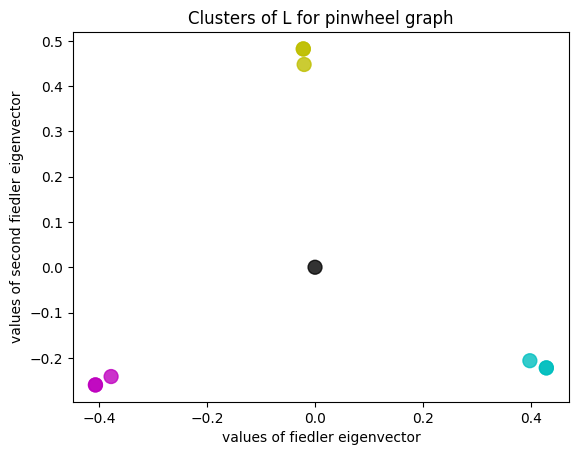

In [451]:
###############
### Cell 19 ###
###############

L = nx.linalg.normalized_laplacian_matrix(pinwheel_graph)
fiedler_vectors = get_k_fiedler_eigenvectors_sparse(L, 2)
colors = get_colors_from_clusters(fiedler_vectors, num_clusters=4)
show_2D_scatterplot(fiedler_vectors[:,0],
                    fiedler_vectors[:,1],
                    colors,
                    xlabel = "values of fiedler eigenvector",
                    ylabel = "values of second fiedler eigenvector",
                    title = "Clusters of L for pinwheel graph")

Show partition from the classes discovered when we cluster the values of the fiedler eigenvectors.

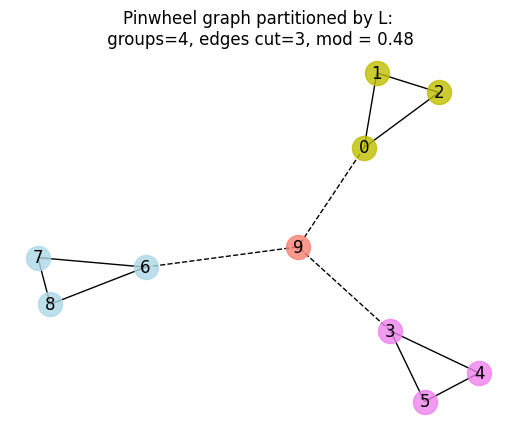

In [452]:
###############
### Cell 20 ###
###############
group1 = {node for node in pinwheel_graph.nodes() if colors[node] == 'y'}
group2 = {node for node in pinwheel_graph.nodes() if colors[node] == 'c'}
group3 = {node for node in pinwheel_graph.nodes() if colors[node] == 'm'}
group4 = {node for node in pinwheel_graph.nodes() if colors[node] == 'k'}


# Spring layout tends to show core periphery structure well
show_partitions(pinwheel_graph, 
                pos = nx.spring_layout(pinwheel_graph),
                partition=(group1, group2, group3, group4), 
                title="Pinwheel graph partitioned by L:\n")

Let's see what happens when we cluster using the spectra of the adjacency matrix.

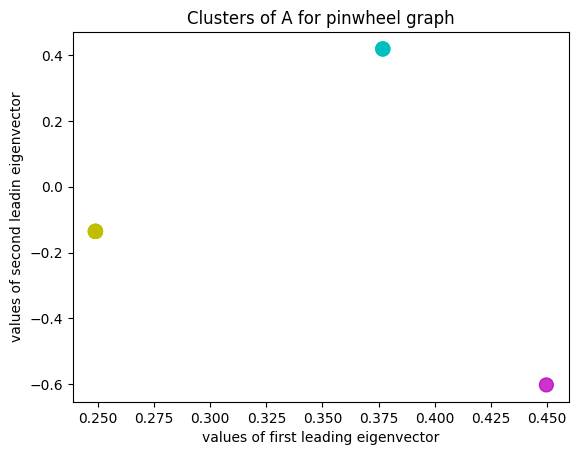

In [453]:
###############
### Cell 21 ##
###############

A = nx.linalg.adjacency_matrix(pinwheel_graph)
leading_vectors = get_k_principal_eigenvectors_sparse(A, 2)
colors = get_colors_from_clusters(leading_vectors, num_clusters=3)

show_2D_scatterplot(leading_vectors[:,0],
                    leading_vectors[:,1],
                    colors,
                    xlabel = "values of first leading eigenvector",
                    ylabel = "values of second leadin eigenvector",
                    title = "Clusters of A for pinwheel graph")

And show which nodes are in each partition

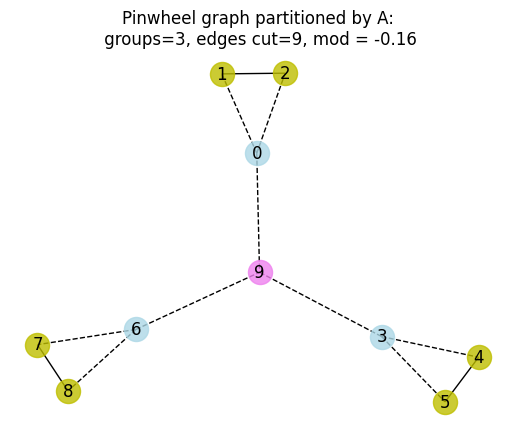

In [454]:
###############
### Cell 22 ###
###############
group1 = {node for node in pinwheel_graph.nodes() if colors[node] == 'y'}
group2 = {node for node in pinwheel_graph.nodes() if colors[node] == 'c'}
group3 = {node for node in pinwheel_graph.nodes() if colors[node] == 'm'}
#group4 = {node for node in pinwheel_graph.nodes() if colors[node] == 'k'}
#group5 = {node for node in pinwheel_graph.nodes() if colors[node] == 'red'}


# Spring layout tends to show core periphery structure well
show_partitions(pinwheel_graph, 
                pos = nx.spring_layout(pinwheel_graph),
                partition=(group1, group2, group3), 
                title="Pinwheel graph partitioned by A:\n")

Notice how the nodes are clustered by their centrality scores. In other words, the nodes are clustered by the "structured role" that the nodes play in their local networks. We'll formalize the idea of "structured role" in a later lecture.

---

#### Core-periphery Network With Strong Structure
Let's construct a core-periphery graph with a lot more structure and see if the "two-ways" hypothesis works better for that network.

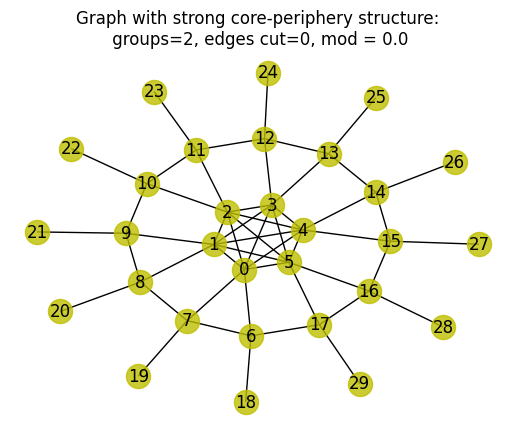

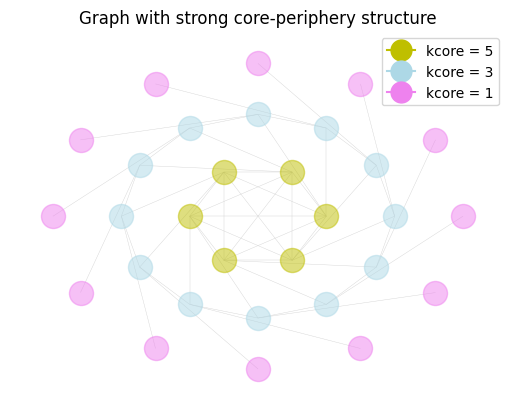

In [455]:
###############
### Cell 23 ###
###############

import matplotlib.pyplot as plt

G: nx.Graph = nx.complete_graph(6)
G.add_nodes_from(list(range(6,30)))
G.add_edges_from([(0,6), (0,7), (6,7),
                  (1,8), (1,9), (8,9),
                  (2,10), (2,11), (10,11),
                  (3,12), (3,13), (12,13),
                  (4,14), (4,15), (14,15),
                  (5,16), (5,17), (16,17),
                  (6,18), (7,19), (8,20), (9,21),
                  (10,22), (11,23), (12,24), (13,25),
                  (14,26), (15,27), (16,28), (17,29)])
G.add_edges_from([(7,8), (9,10), (11,12), (13,14), (15,16),(17,6)])

plt.figure()

show_partitions(G, 
                pos = nx.nx_pydot.pydot_layout(G,"neato"),
                partition=(set(G.nodes), set()), 
                title="Graph with strong core-periphery structure:\n")
plt.figure()
show_kCores(G, title="Graph with strong core-periphery structure")

Partition using spectrum of the Laplacian matrix

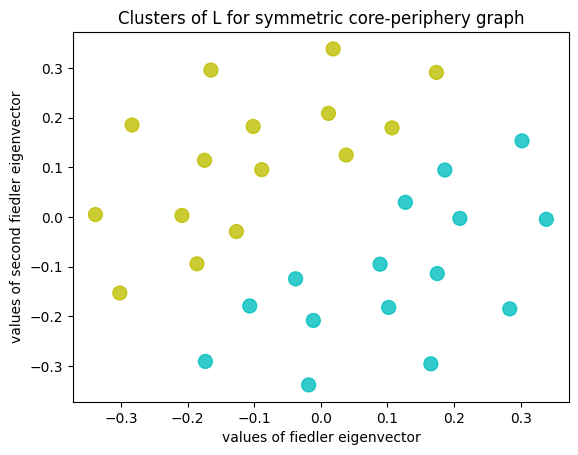

In [456]:
###############
### Cell 24 ###
###############
# Fix the random seed so that we get consistent results
# The eigenvalue solver used has a stochastic element
import numpy as np
np.random.seed(42)

L = nx.linalg.normalized_laplacian_matrix(G)
fiedler_vectors = get_k_fiedler_eigenvectors_sparse(L, 2)
colors = get_colors_from_clusters(fiedler_vectors, num_clusters=2)
show_2D_scatterplot(fiedler_vectors[:,0],
                    fiedler_vectors[:,1],
                    colors,
                    xlabel = "values of fiedler eigenvector",
                    ylabel = "values of second fiedler eigenvector",
                    title = "Clusters of L for symmetric core-periphery graph")

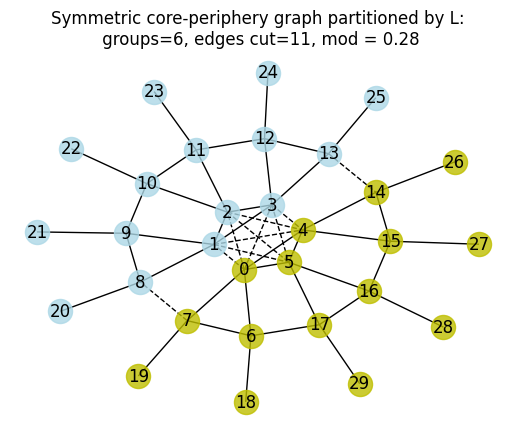

In [457]:
###############
### Cell 25 ###
###############
group1 = {node for node in G.nodes() if colors[node] == 'y'}
group2 = {node for node in G.nodes() if colors[node] == 'c'}
group3 = {node for node in G.nodes() if colors[node] == 'm'}
group4 = {node for node in G.nodes() if colors[node] == 'k'}
group5 = {node for node in G.nodes() if colors[node] == 'red'}
group6 = {node for node in G.nodes() if colors[node] == 'green'}


# Spring layout tends to show core periphery structure well
show_partitions(G, 
                pos = nx.nx_pydot.pydot_layout(G,"neato"),
                partition=(group1, group2, group3, group4, group5, group6), 
                title="Symmetric core-periphery graph partitioned by L:\n")

Partition using the spectra of the adjacency matrix

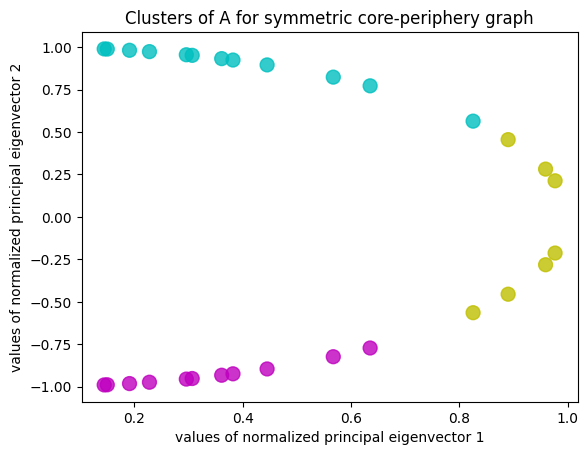

In [466]:
###############
### Cell 26 ##
###############
np.random.seed(42)

A = nx.linalg.adjacency_matrix(G)
principal_vectors = get_k_principal_eigenvectors_sparse(A, 2)
principal_vectors = principal_vectors / np.linalg.norm(principal_vectors, axis=1, keepdims=True)
colors = get_colors_from_clusters(principal_vectors, num_clusters=3)

show_2D_scatterplot(principal_vectors[:,0],
                    principal_vectors[:,1],
                    colors,
                    xlabel = "values of normalized principal eigenvector 1",
                    ylabel = "values of normalized principal eigenvector 2",
                    title = "Clusters of A for symmetric core-periphery graph")

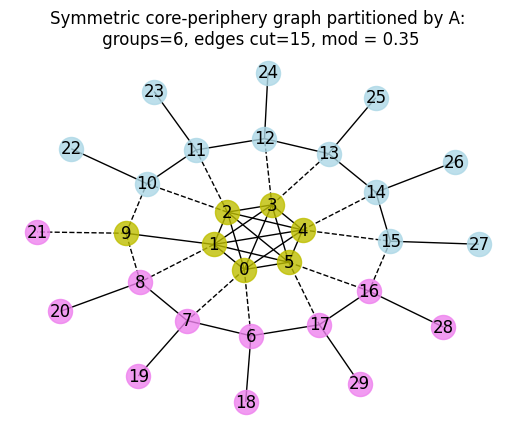

In [467]:
###############
### Cell 27 ###
###############
group1 = {node for node in G.nodes() if colors[node] == 'y'}
group2 = {node for node in G.nodes() if colors[node] == 'c'}
group3 = {node for node in G.nodes() if colors[node] == 'm'}
group4 = {node for node in G.nodes() if colors[node] == 'k'}
group5 = {node for node in G.nodes() if colors[node] == 'red'}
group6 = {node for node in G.nodes() if colors[node] == 'green'}


# Spring layout tends to show core periphery structure well
show_partitions(G, 
                pos = nx.nx_pydot.pydot_layout(G,"neato"),
                partition=(group1, group2, group3, group4, group5, group6), 
                title="Symmetric core-periphery graph partitioned by A:\n")

Notice that eigenvalues are not unique for this adjacency matrix. Choosing just two eigenvectors won't do a good job.

In [460]:
A = nx.linalg.adjacency_matrix(G)
B = A.toarray()
eigenvalues, eigenvectors = np.linalg.eig(B)
print(sorted([float(np.round(ev, 2)) for ev in eigenvalues], reverse=True))

[5.59, 2.63, 2.63, 2.02, 2.02, 1.89, 1.48, 1.0, 0.68, 0.68, 0.47, 0.47, 0.41, -0.23, -0.23, -0.27, -0.27, -0.31, -0.47, -1.0, -1.22, -1.22, -1.55, -1.55, -2.17, -2.21, -2.21, -2.33, -2.33, -2.41]


--- 

### Clustering Using More Information

The scatter plot won't work well since we are using more than 2 eigenvectors

Text(0.5, 1.0, 'Values of principal eigenvector for symmetric core-periphery graph')

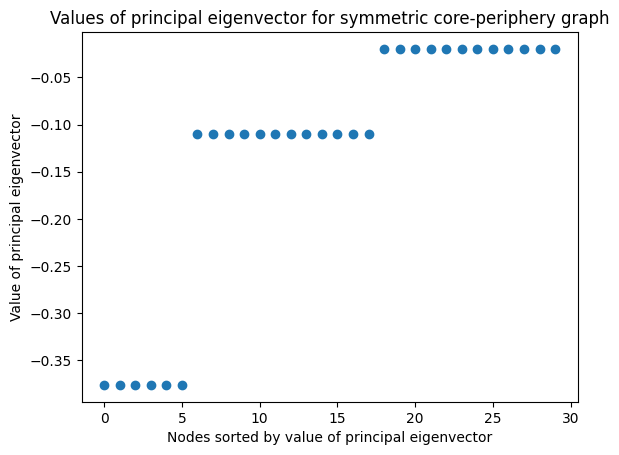

In [482]:
num_eigenvectors: int = 10
A = nx.linalg.adjacency_matrix(G)
principal_vectors = get_k_principal_eigenvectors_sparse(A, num_eigenvectors)

# Plot the values of the principal eigenvector from smallest to largest
# The x axis is just the node labels sorted by the value of the principal eigenvector
plt.figure()
plt.scatter(range(len(G.nodes())), principal_vectors[:,0][np.argsort(principal_vectors[:,0])])
plt.xlabel("Nodes sorted by value of principal eigenvector")
plt.ylabel("Value of principal eigenvector")
plt.title("Values of principal eigenvector for symmetric core-periphery graph")


Show the partitioning from finding groups of just the principal eigenvector.

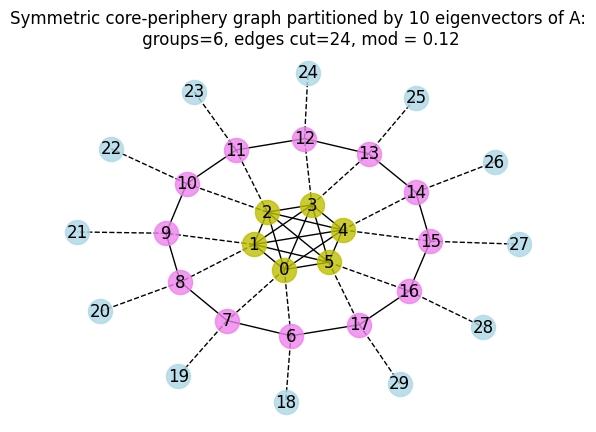

In [487]:
from partitioning_utilities import get_partition_from_single_eigenvector

clusters = get_partition_from_single_eigenvector(
    principal_vectors[:, 0],
    nodes=sorted(G.nodes()),
    method="kmeans",
    num_clusters=3,
)

color_template = ['y', 'c', 'm', 'k', 'red', 'green']
colors = [None] * len(G.nodes())
for i, cluster in enumerate(clusters):
    for node in cluster:
        colors[node] = color_template[i % len(color_template)]

group1 = {node for node in G.nodes() if colors[node] == 'y'}
group2 = {node for node in G.nodes() if colors[node] == 'c'}
group3 = {node for node in G.nodes() if colors[node] == 'm'}
group4 = {node for node in G.nodes() if colors[node] == 'k'}
group5 = {node for node in G.nodes() if colors[node] == 'red'}
group6 = {node for node in G.nodes() if colors[node] == 'green'}


# Spring layout tends to show core periphery structure well
show_partitions(G, 
                pos = nx.nx_pydot.pydot_layout(G,"neato"),
                partition=(group1, group2, group3, group4, group5, group6), 
                title=f"Symmetric core-periphery graph partitioned by {num_eigenvectors} eigenvectors of A:\n")


If I plot the graph by k-cores, I should see the division by core and periphery well.

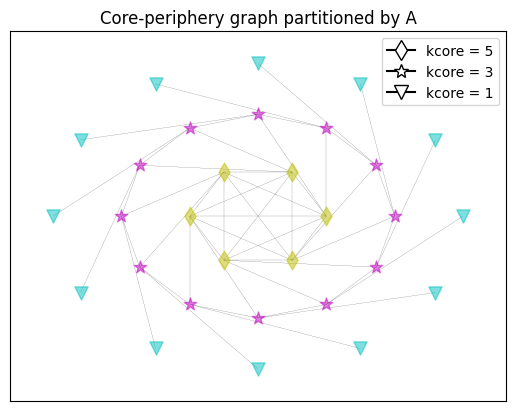

In [488]:
show_kCores_by_partition(G,colors, title="Core-periphery graph partitioned by A")

What happens if I use more more of the principal eigenvectors

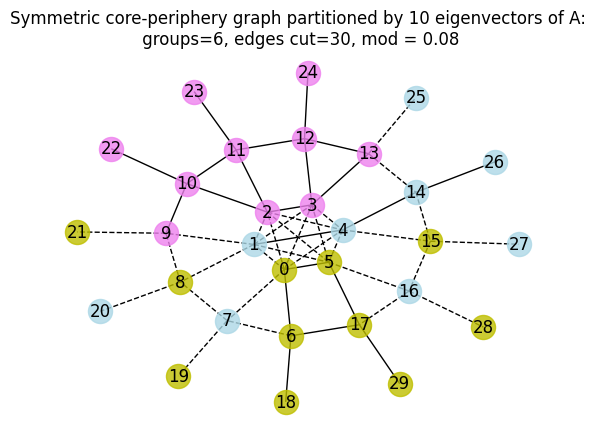

In [485]:
colors = get_colors_from_clusters(principal_vectors, num_clusters=3)

group1 = {node for node in G.nodes() if colors[node] == 'y'}
group2 = {node for node in G.nodes() if colors[node] == 'c'}
group3 = {node for node in G.nodes() if colors[node] == 'm'}
group4 = {node for node in G.nodes() if colors[node] == 'k'}
group5 = {node for node in G.nodes() if colors[node] == 'red'}
group6 = {node for node in G.nodes() if colors[node] == 'green'}


# Spring layout tends to show core periphery structure well
show_partitions(G, 
                pos = nx.nx_pydot.pydot_layout(G,"neato"),
                partition=(group1, group2, group3, group4, group5, group6), 
                title=f"Symmetric core-periphery graph partitioned by {num_eigenvectors} eigenvectors of A:\n")

This is off, so plotting the graph by k-cores will look bad.

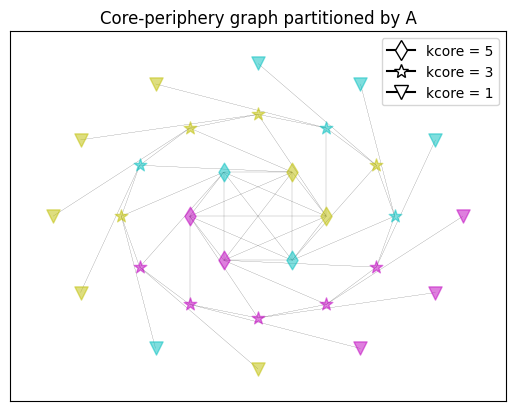

In [486]:
show_kCores_by_partition(G,colors, title="Core-periphery graph partitioned by A")

## Why Does Partitioning by a Single Eigenvector of $A$ Work Better Than Using Multiple Eigenvectors?

This is a core illustration of the **two-truths phenomenon**.

### The principal eigenvector encodes centrality (role)

By the **Perron-Frobenius theorem**, the principal eigenvector of a non-negative symmetric matrix has a special property: its entry values are proportional to each node's **eigenvector centrality**. For this graph, the three structural tiers have clearly different centralities:

| Tier | Nodes | Centrality |
|------|-------|------------|
| Core clique $K_6$ | 0–5 | Very high |
| Middle ring | 6–17 | Moderate |
| Outer leaves | 18–29 | Low |

The principal eigenvector values therefore fall into **three tight, well-separated clusters** — one per tier. A 1D $k$-means cut is essentially perfect.

### Adding more eigenvectors hurts because of repeated eigenvalues

This graph has **6-fold rotational symmetry** (6 identical spokes attached to the core). That symmetry produces **repeated eigenvalues** — as you can verify by printing the sorted spectrum above. When eigenvalues are repeated, the eigenvectors for those eigenvalues are not unique: any orthogonal basis for the eigenspace is equally valid, and the solver returns an arbitrary one. Concretely:

- Eigenvectors 2, 3, 4, ... encode *which spoke* a node belongs to, not which tier it is in.
- Node 0 (core, spoke 1) and node 3 (core, spoke 4) have the same tier but very different values in spoke-distinguishing eigenvectors.

When you cluster in the multi-eigenvector embedding, the algorithm sees the **spoke-identity signal** in those later eigenvectors and starts grouping nodes from the same spoke together rather than by core/periphery tier. The tier signal is diluted by the spoke signal.

### The "two truths"

This is the central insight of the Priebe et al. (2019) paper cited at the top of this notebook:

| Matrix | Eigenvectors primarily encode | Best reveals |
|--------|-------------------------------|--------------|
| Normalized Laplacian $L$ | **Community membership** (which spoke/module) | Affinity/community networks |
| Adjacency $A$ (principal only) | **Role/centrality** (core vs. periphery tier) | Core-periphery networks |

The "two truths" are that both answers are correct — they just answer *different questions* about the network structure.
